## Importing

### Meeting - Nicolas Courty (20/03)

- Different solvers for optimal transport can allow multiple solutions. The simplest OT solver has a bijection solution. However, sinkhorn allows the mass to be distributed unevenly and therefore not bijection anymore. The regularization parameter is essencial as give space to how tight the optimtransport plan should be. 

- In addition, prof. Nicolas reccomend do not transport the full image of size (2000x2000) into another bigger image, even tho we are talking about the embeddings of it. He points out that the domain shift for an object detection of dugong is local by nature. Therefore, he would reccomend to look at the patch embeddings and transport the distribution patch source from the target. 

- He points out that this image size is too much information being transported but also too much information presented on the embedding that could be poorly translated to the detection of dugong itself. 

- Optimal transport would have an limitation regarding dataset size, he pointed out that datasets >> 10,000. would be too big for OT problems. 

- To sum up, he recommend literature three different approach, first: flow matching; deppjdot; jumbot.

- Regarding how to execute an active learning and sample the best image set in order to select an optimal set of images to be labelled, he come out  with 2-sasmple Wasserstein Test. 

In [1]:
## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [ ]:
import fiftyone.brain as fob
from sklearn.preprocessing import normalize
import plotly.express as px
import skdim
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ot
from sklearn.manifold import TSNE
import cv2
from fiftyone import ViewField as F
import plotly.graph_objects as go
import plotly.express as px
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.palettes import Category10


In [106]:
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.load_saved_view("New_Caledonia")
wp_view = dataset.load_saved_view("West_Papua")

In [4]:
## get embeddings for each view and normalize it 
## retrieve values
nc_emb = nc_view.values("full_embeddings")
wp_emb = wp_view.values("full_embeddings")

## convert to array
nc_emb = np.array(nc_emb)
wp_emb = np.array(wp_emb)

## normalize firsrt
nc_norm = normalize(nc_emb)
wp_norm = normalize(wp_emb)


In [38]:
## CREATE VIEWS OF THE DATASET THAT ARE REPRESENTATIVE OF GEOGRAPHICAL LOCATIONS
## NOTE : Mantasandy is being excluded from further analysis because
## it only has 3 images inside the folder. 
view_GAM = wp_view.match(
    F("subregion")=="GAM"
)
view_FRIWEN = wp_view.match(
    F("subregion")=="FRIWEN"
)
view_MANTASANDY = wp_view.match(
    F("subregion")=="MANTASANDY"
)
view_UM = wp_view.match(
    F("subregion")=="UM"
)
gam_emb = view_GAM.values('full_embeddings')
friwen_emb = view_FRIWEN.values('full_embeddings')
um_emb = view_UM.values('full_embeddings')

norm_gam_emb = normalize(gam_emb)
norm_friwen_emb = normalize(friwen_emb)
norm_um_emb = normalize(um_emb)

print(f"WP- GAM: {len(view_GAM)}")
print(f"WP - FRIWEN: {len(view_FRIWEN)}")
print(f"WP - MANTASANDY: {len(view_MANTASANDY)}")
print(f"WP -UM: {len(view_UM)}")
print(f"NC: {len(nc_view)}")
print(f"WP (total): {len(wp_view)}")

datasets_l ={'WP': wp_norm, 
             'NC' : nc_norm,
            'WP_GAM':norm_gam_emb,
            'WP_friwen':norm_friwen_emb,
            'WP_mant':norm_um_emb}



WP- GAM: 512
WP - FRIWEN: 779
WP - MANTASANDY: 3
WP -UM: 745
NC: 716
WP (total): 2039


In [ ]:
data= []
for sample in dataset.select_fields(["region", "subregion", "ground_truth"]):
    data.append({
        "region": sample.region,
        "subregion": sample.subregion,
        "obj_count": len(sample.ground_truth.detections) if sample.ground_truth else 0
    })

# 2. Convert to DataFrame
df = pd.DataFrame(data)
##df

df[['subregion','obj_count']].groupby(by='subregion').sum().plot(kind='bar')

,region,subregion,obj_count
0,NC,NC,1
1,NC,NC,1
2,NC,NC,1
3,NC,NC,1
4,NC,NC,1
...,...,...,...
2750,WP,UM,1
2751,WP,UM,1
2752,WP,UM,2
2753,WP,UM,4


# MLE

## Full image

In [ ]:
import time
from contextlib import contextmanager

@contextmanager
def timer(name):
    start = time.perf_counter()
    yield
    end = time.perf_counter()
    print(f"{name}: {end - start:.4f} s")
    
def calculate_MLE(dataset: np.ndarray, 
                  list_neighboors: list = [3,5,10,20],
                  verbose=True):
    """
    Computes Maximum Likelihood Estimation for a set of neighboors,
    Returns:
        dict of MLE distances for each neighboor
    """
    def compute(dataset, 
                n_neighboors: int,
                n_jobs: int = 1):
        """
        Returns a float containing the intrinsic measure. 
        """
        mlea = skdim.id.MLE().fit_transform(X = dataset,
                                                n_neighbors = n_neighboors,
                                                n_jobs = 1)
        return mlea 
        
    results = {}
    for k in list_neighboors:
        if verbose:
            print(f"running {k}")
            with timer(f'k_{k}'):
                mlea = compute(dataset,
                               n_neighboors = k)
                results[k] = mlea
        else:
            mlea = compute(dataset,
                           n_neighboors = k)
            results[k] = mlea
    return results


In [22]:
# Configuration
sample_sizes = [50, 100, 250, 500, 700]
neighbors_list = [3, 5, 10, 20]
n_iterations = 15

results_list = []

for name, data in datasets_l.items():
    print(f"Processing: {name}")
    for n in sample_sizes:
        if n > data.shape[0]: continue 
        
        for i in range(n_iterations):
            idx = np.random.choice(data.shape[0], size=n, replace=False)
            # Calculate MLE for all k at once for this specific sample
            res = calculate_MLE(dataset=data[idx],
                                 list_neighboors=neighbors_list,
                                 verbose=False)
            
            for k, val in res.items():
                results_list.append({
                    'Dataset': name,
                    'Sample Size': n,
                    'k': k,
                    'MLE': val
                })

df_interaction = pd.DataFrame(results_list)


Processing: WP
Processing: NC
Processing: WP_GAM
Processing: WP_friwen
Processing: WP_mant


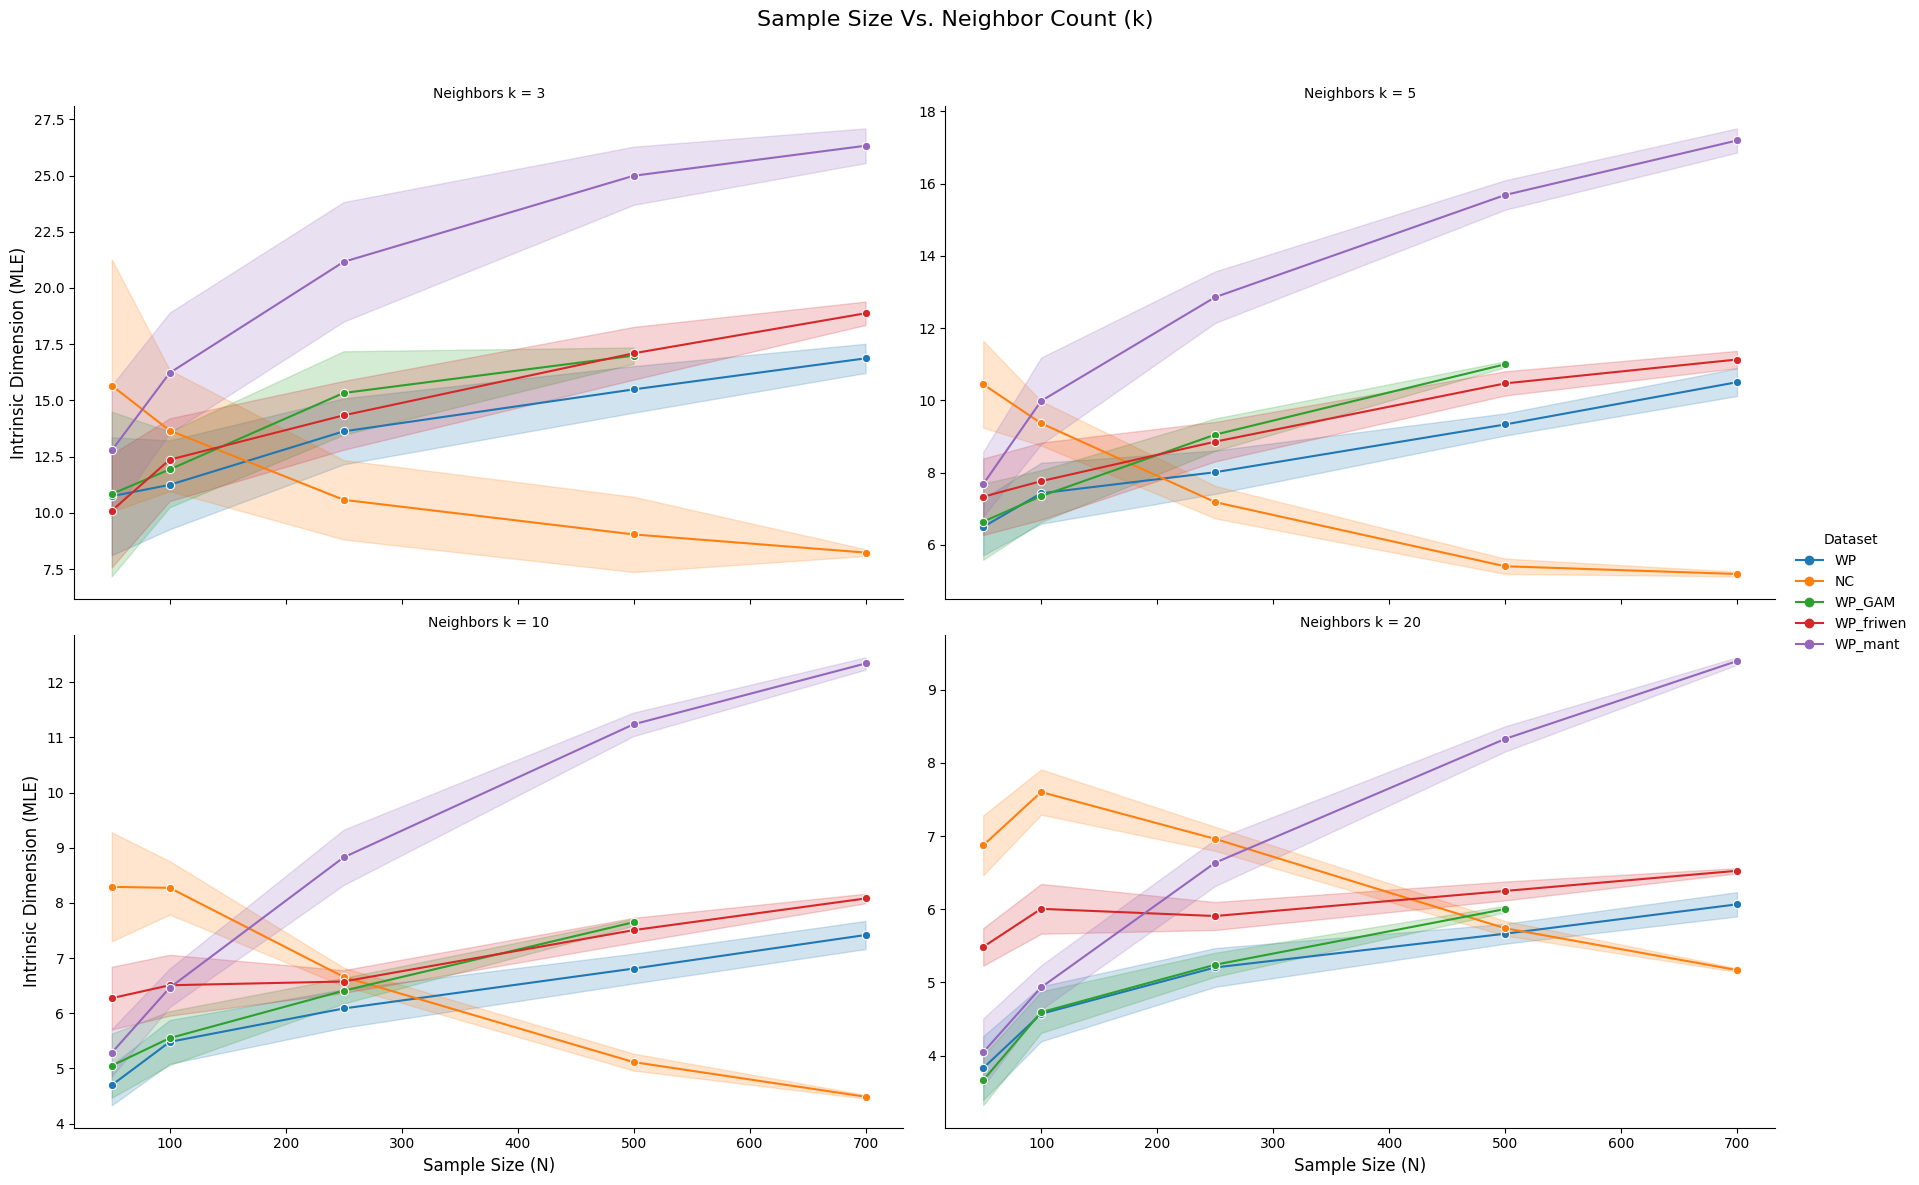

In [25]:
# plot
g = sns.relplot(
    data=df_interaction, 
    x='Sample Size', 
    y='MLE', 
    hue='Dataset', 
    col='k', 
    kind='line', 
    marker='o', 
    facet_kws={'sharey': False},
    errorbar='sd',
    col_wrap = 2,
    height = 6,
    aspect = 1.5
)

g.set_axis_labels("Sample Size (N)", "Intrinsic Dimension (MLE)",
                 fontsize=12)
g.set_titles("Neighbors k = {col_name}",fontsize=20)
plt.subplots_adjust(top=0.90)
g.fig.suptitle('Sample Size Vs. Neighbor Count (k)',fontsize=16)

plt.show()

## MLE - Bounding Box

Here we are exploring the MLE for the patches of images. Where it relies the dugong information. 

In [41]:
## retrieve the embeddings for each view 
##nested_embeddings = dataset.values("ground_truth.detections.patch_embeddings")

## creates a function
def flatten_nested_embeddings(nested_embeddings):
    """
    Returns a embeddings of shape:
        Total detections, 1024.
    """
    # flatten and avoid null/none values
    final_list = [
        emb for sublist in nested_embeddings 
        if sublist is not None 
        for emb in sublist 
        if emb is not None
    ]
    return np.vstack(final_list)


In [45]:
## retrieve the embeddings for the view
## some images can contain more detections that others
nest_emb_NC = flatten_nested_embeddings(
    nc_view.values('ground_truth.detections.patch_embeddings')
)
nest_emb_WP =  flatten_nested_embeddings(
    wp_view.values('ground_truth.detections.patch_embeddings')
)
nest_emb_WP_GAM =  flatten_nested_embeddings(
    view_GAM.values('ground_truth.detections.patch_embeddings')
)
nest_emb_WP_FRIWEN =  flatten_nested_embeddings(
    view_FRIWEN.values('ground_truth.detections.patch_embeddings')
)
nest_emb_WP_UM =  flatten_nested_embeddings(
    view_UM.values('ground_truth.detections.patch_embeddings')
)

print(f"GAM size:{nest_emb_WP_GAM.shape}")
print(f"UM: {nest_emb_WP_UM.shape}")
print(f"FRIWEN: {nest_emb_WP_FRIWEN.shape}")
print(f"NC: {nest_emb_NC.shape}")
print(f"WP - full :{nest_emb_WP.shape}")

GAM size:(997, 1024)
UM: (1308, 1024)
FRIWEN: (1307, 1024)
NC: (3546, 1024)
WP - full :(3615, 1024)


In [178]:
## compute the MLE for all the dataset and plot it
datasets_l ={'WP': nest_emb_WP, 
             'NC' : nest_emb_NC,
             'WP_GAM': normalize(nest_emb_WP_GAM),
             'WP_FRIWEN':normalize(nest_emb_WP_FRIWEN),
             'WP_UM':normalize(nest_emb_WP_UM)}

output = {}
for k,v in datasets_l.items():
    print(f"Running:{k}")
    results = calculate_MLE(dataset = v,
                            list_neighboors=[3,5,10,20],
                           verbose=False)
    output[k] = results


## throw in a df
df = pd.DataFrame().from_dict(output)
df  = df.reset_index().rename(columns={'index':'N_neighboor'})

df_melted = df.melt(id_vars = 'N_neighboor',
                    var_name='Group',
                    value_name='Value'
                   )

df_melted

Running:WP


Running:NC
Running:WP_GAM
Running:WP_FRIWEN
Running:WP_UM


,N_neighboor,Group,Value
0,3,WP,36.061084
1,5,WP,24.201673
2,10,WP,19.962177
3,20,WP,17.768702
4,3,NC,36.740668
5,5,NC,25.807747
6,10,NC,21.809118
7,20,NC,20.451368
8,3,WP_GAM,26.308241
9,5,WP_GAM,18.305889


In [179]:
fig = px.histogram(
    df_melted,
    x="Group",          # categories on x-axis
    y="Value",          # numeric values on y-axis
    color="N_neighboor",
    barmode="group",
  ##  orientation="v",
    text_auto='.2s',
    color_discrete_sequence=px.colors.qualitative.Pastel1,  # palette
    title="MLE of object detection embeddings",
)

fig.update_layout(
    xaxis_title=None,
    yaxis_title="Num of Intrinsic Dimensions",
    template="plotly_white",
    width=900,
    height=500
)

fig.show()

In [49]:
# Configuration
sample_sizes = [50, 100, 250, 500, 700]
neighbors_list = [3, 5, 10, 20]
n_iterations = 15

results_list = []

for name, data in datasets_l.items():
    print(f"Processing: {name}")
    for n in sample_sizes:
        if n > data.shape[0]: continue 
        
        for i in range(n_iterations):
            idx = np.random.choice(data.shape[0], size=n, replace=False)
            # Calculate MLE for all k at once for this specific sample
            res = calculate_MLE(dataset=data[idx],
                                 list_neighboors=neighbors_list,
                                 verbose=False)
            
            for k, val in res.items():
                results_list.append({
                    'Dataset': name,
                    'Sample Size': n,
                    'k': k,
                    'MLE': val
                })

df_interaction = pd.DataFrame(results_list)


Processing: WP
Processing: NC
Processing: WP_GAM
Processing: WP_FRIWEN
Processing: WP_UM


In [ ]:
## same plot but in plotly
k_values = sorted(df_interaction['k'].unique())
datasets = df_interaction['Dataset'].unique()
colors = px.colors.qualitative.Plotly

MARKER_SYMBOLS = {
    'Dataset1': 'circle',
    'Dataset2': 'square',
    'Dataset3': 'diamond',
    'WP':       'hash',    
}

LINE_STYLES = {
    'Dataset1': 'solid',
    'Dataset2': 'solid',
    'Dataset3': 'solid',
    'WP':       'dash',        # dashed for the composite dataset
}

def hex_to_rgba(color, alpha=0.2):
    """Convert any plotly color to rgba with given alpha."""
    if color.startswith('#'):
        r, g, b = int(color[1:3], 16), int(color[3:5], 16), int(color[5:7], 16)
        return f'rgba({r},{g},{b},{alpha})'
    elif color.startswith('rgb('):
        return color.replace('rgb(', f'rgba(').replace(')', f', {alpha})')
    return color

def build_traces(k_val):
    traces = []
    df_k = df_interaction[df_interaction['k'] == k_val]

    for j, dataset in enumerate(datasets):
        df_sub = df_k[df_k['Dataset'] == dataset].copy()
        agg = df_sub.groupby('Sample Size')['MLE'].agg(['mean', 'std']).reset_index()
        agg.columns = ['Sample Size', 'mean', 'std']
        agg = agg.sort_values('Sample Size')

        color      = colors[j % len(colors)]
        fill_color = hex_to_rgba(color, alpha=0.15)
        marker_sym = MARKER_SYMBOLS.get(dataset, 'circle')
        line_dash  = LINE_STYLES.get(dataset, 'solid')

        # Error band
        traces.append(go.Scatter(
            x=pd.concat([agg['Sample Size'], agg['Sample Size'][::-1]]),
            y=pd.concat([agg['mean'] + agg['std'], (agg['mean'] - agg['std'])[::-1]]),
            fill='toself',
            fillcolor=fill_color,
            line=dict(color='rgba(0,0,0,0)'),
            showlegend=False,
            hoverinfo='skip',
            name=f'{dataset}_band',
        ))

        # Line + markers
        traces.append(go.Scatter(
            x=agg['Sample Size'],
            y=agg['mean'],
            mode='lines+markers',
            name=str(dataset),
            legendgroup=str(dataset),
            line=dict(color=color, width=2, dash=line_dash),   # ← dash here
            marker=dict(
                symbol=marker_sym,                             # ← marker here
                size=9,
                color=color,
                line=dict(color='white', width=1),             # white outline for clarity
            ),
        ))
    return traces

# Build figure with initial k
fig = go.Figure()
for trace in build_traces(k_values[0]):
    fig.add_trace(trace)

# Dropdown buttons — one per k value
buttons = []
for k_val in k_values:
    new_traces = build_traces(k_val)
    buttons.append(dict(
        label=f'k = {k_val}',
        method='update',
        args=[
            {   # update trace data
                'x': [t.x for t in new_traces],
                'y': [t.y for t in new_traces],
                'fillcolor': [t.fillcolor if hasattr(t, 'fillcolor') else None for t in new_traces],
            },
            {   # update layout title
                'title.text': f'Sample Size Vs. Neighbor Count — k = {k_val}',
            }
        ]
    ))

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.01,
        xanchor='left',
        y=1.12,
        yanchor='top',
        bgcolor='white',
        bordercolor='gray',
        font=dict(size=13),
    )],
    title=dict(
        text=f'MLE - Patch Embeddings — k = {k_values[0]}',
        font=dict(size=16),
        x=0.5
    ),
    xaxis_title='Sample Size (N)',
    yaxis_title='MLE',
    legend_title='Dataset: ',
    height=550,
    width=700,
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#eeeeee'),
    yaxis=dict(showgrid=True, gridcolor='#eeeeee'),
)

fig.show()

# Enrichment of Source dataset with random choosen target

- This is the size of our datasets:
```bash
    WP- GAM: 512
    WP - FRIWEN: 779
    WP MANTASANDY: 3
    WP UM: 745
    WP total: 2039
    NC: 716
```
To compose a representative sampling of WP we are doing a weighting selection where:
$$
WP = \frac{512}{Total} * WP_{GAM} + \frac{779}{Total} * WP_{FRIWEN} + 745/Total + {WP_MANTASANDY}
WP = 0.25*GAM + 0.38+FRIWEN + 0.36*MANTASANDY
$$


In [ ]:
def return_sample_size(percentage,
                        len_total:int = len(wp_view),
                        size_wp:int  = len(wp_view) -3, ## subtract 3 images from MANSANDY
                        len_gam:int = len(view_GAM),
                        len_um:int = len(view_UM),
                        len_friwen:int = len(view_FRIWEN)):
    """
    Calculate the number of samples that should be taken from each
    geographical region. 
    The percentage is dependent on the len_total. Which can
    represent either WP or NC
    Args:
        len_total = the maximum total length to be fractioned
        size_wp = size of the West Papua which holds the others dataset
    """
    prc = percentage
    num_addition = int(len_total*prc)
    
    size_gam = int((len_gam / size_wp)*num_addition)
    size_um = int((len_um/size_wp)*num_addition)
    size_friwen = int((len_friwen/size_wp)*num_addition)

    return {'gam':size_gam,'um': size_um,'friwen': size_friwen}

    


### Full Embeddings

In [170]:
## Compute mixing
## ------------------------
## LIST OF IDs
id_gam = view_GAM.values('id')
id_um = view_UM.values('id')
id_friwen = view_FRIWEN.values('id')
dict_id = {'gam':id_gam,'um':id_um,'friwen':id_friwen}

## Loop over different percentage of mixing
results_list = []
for perct in [0.05, 0.1,0.15,0.2, 0.25,0.3, 0.35, 0.4, 0.45,
               0.5,0.55,0.6,0.7, 0.75,0.8,0.9,0.95]:
    dict_samplers_size = return_sample_size(percentage=perct,
                                             len_total = len(nc_view),
                                            size_wp  = len(wp_view) -3, ## subtract 3 images from MANSANDY
                                            len_gam = len(view_GAM),
                                            len_um = len(view_UM),
                                            len_friwen = len(view_FRIWEN)
                                             )
    print(f"Running {perct*100}% of mixing - WP size sample = {np.sum(list(dict_samplers_size.values()))}  ")

    assert dict_id.keys()== dict_samplers_size.keys()

    ## loop over the subregions to the proper id
    dict_sampled_id_per_region = {}
    for reg in dict_id.keys():
        ##print(f"Subregion: {reg}")
        dict_sampled_id_per_region[reg] = random.sample(
                                                dict_id[reg], ## name of hte region
                                                dict_samplers_size[reg], ## number of samples
                                            )
        
    ## SLICE DATASET - SELECT PARCIAL WP + NC 
    ## the dataset now is mixed of all NC + 10% of WP
    ## where WP is the flatten id of the dict.
    ## To solve this, I am appending all NC into the WP and slicing from dataset
    parcial_wp_id = np.concatenate(list(dict_sampled_id_per_region.values()))
    frac_dataset_id = np.concat((parcial_wp_id,nc_view.values('id')), 
                                axis=0)

    ## crate a view over the dataset selecting the samples
    frac_dataset = dataset[frac_dataset_id.flatten().tolist()]

    ## full embeddings 
    full_embeddings = frac_dataset.values('full_embeddings')
    norm_full_emb = normalize(full_embeddings)

    ## compute MLE looping for each value of K neighboor
    # Calculate MLE for all k at once for this specific sample
    res = calculate_MLE(dataset=norm_full_emb,
                        list_neighboors=[3,5,10,20],
                        verbose=False
                        )
                
    for k, val in res.items():
        results_list.append({
                'num_of_wp_samples':np.sum(list(dict_samplers_size.values())),
                'percentage_wp': perct*100,
                'k': k,
                'MLE': val
                })
        
## create a final df
df_finale = pd.DataFrame(results_list)
df_finale.head() 

Running 5.0% of mixing - WP size sample = 33  
Running 10.0% of mixing - WP size sample = 69  
Running 15.0% of mixing - WP size sample = 105  
Running 20.0% of mixing - WP size sample = 141  
Running 25.0% of mixing - WP size sample = 178  


Running 30.0% of mixing - WP size sample = 212  
Running 35.0% of mixing - WP size sample = 248  
Running 40.0% of mixing - WP size sample = 284  
Running 45.0% of mixing - WP size sample = 320  
Running 50.0% of mixing - WP size sample = 356  
Running 55.00000000000001% of mixing - WP size sample = 391  
Running 60.0% of mixing - WP size sample = 427  
Running 70.0% of mixing - WP size sample = 499  
Running 75.0% of mixing - WP size sample = 536  
Running 80.0% of mixing - WP size sample = 570  
Running 90.0% of mixing - WP size sample = 642  
Running 95.0% of mixing - WP size sample = 679  


,num_of_wp_samples,percentage_wp,k,MLE
0,33,5.0,3,8.374900
1,33,5.0,5,5.394621
2,33,5.0,10,4.634379
3,33,5.0,20,5.267722
4,69,10.0,3,8.231742


In [171]:
## save the dataset for further analysis
output_fold = '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/MLE'
filename = "full_emb_mixing_wp_nc_MLE.csv"
df_finale.to_csv(os.path.join(output_fold,filename))

In [172]:

output_notebook()

K = sorted(df_finale['k'].unique())
MARKERS = ['hex', 'circle_x', 'triangle', 'circle']
colors = Category10[len(K)]

p = figure(title="Enrichment of NC",
           background_fill_color="#fafafa")
p.xaxis.axis_label = 'Enrichment (%)'
p.yaxis.axis_label = 'Intrinsic Dimension - MLE'

for i, k in enumerate(K):
    df_k = df_finale[df_finale['k'] == k].sort_values('percentage_wp')
    
    # Line
    p.line(x='percentage_wp', y='MLE', source=df_k,
           color=colors[i], line_width=2,
           legend_label=str(k))
    
    # Markers on top of the line
    p.scatter(x='percentage_wp', y='MLE', source=df_k,
              color=colors[i], marker=MARKERS[i],
              size=10, fill_alpha=0.6,
              legend_label=str(k))

p.legend.location = "top_left"
p.legend.title = "Number of Neighboors"
p.legend.click_policy = "hide" 

show(p)

Loading BokehJS ...

### Patch Embeddings

In [173]:
## Compute mixing
## ------------------------
## LIST OF IDs
id_gam = view_GAM.values('id')
id_um = view_UM.values('id')
id_friwen = view_FRIWEN.values('id')
dict_id = {'gam':id_gam,'um':id_um,'friwen':id_friwen}

## Loop over different percentage of mixing
results_list = []
for perct in [0.05, 0.1,0.15,0.2, 0.25,0.3, 0.35, 0.4, 0.45,
               0.5,0.55,0.6,0.7, 0.75,0.8,0.9,0.95]:
    dict_samplers_size = return_sample_size(percentage=perct,
                                             len_total = len(nc_view),
                                            size_wp  = len(wp_view) -3, ## subtract 3 images from MANSANDY
                                            len_gam = len(view_GAM),
                                            len_um = len(view_UM),
                                            len_friwen = len(view_FRIWEN)
                                             )
    print(f"Running {perct*100}% of mixing - WP size sample = {np.sum(list(dict_samplers_size.values()))}  ")

    assert dict_id.keys()== dict_samplers_size.keys()

    ## loop over the subregions to the proper id
    dict_sampled_id_per_region = {}
    for reg in dict_id.keys():
        ##print(f"Subregion: {reg}")
        dict_sampled_id_per_region[reg] = random.sample(
                                                dict_id[reg], ## name of hte region
                                                dict_samplers_size[reg], ## number of samples
                                            )
        
    ## SLICE DATASET - SELECT PARCIAL WP + NC 
    ## the dataset now is mixed of all NC + 10% of WP
    ## where WP is the flatten id of the dict.
    ## To solve this, I am appending all NC into the WP and slicing from dataset
    parcial_wp_id = np.concatenate(list(dict_sampled_id_per_region.values()))
    frac_dataset_id = np.concat((parcial_wp_id,nc_view.values('id')), 
                                axis=0)

    ## crate a view over the dataset selecting the samples
    frac_dataset = dataset[frac_dataset_id.flatten().tolist()]

    ## PATCH embeddings
    patch_embeddings  =  flatten_nested_embeddings(
                    frac_dataset.values('ground_truth.detections.patch_embeddings')
    ) 
    norm_full_emb = normalize(patch_embeddings)

    ## compute MLE looping for each value of K neighboor
    # Calculate MLE for all k at once for this specific sample
    res = calculate_MLE(dataset=norm_full_emb,
                        list_neighboors=[3,5,10,20],
                        verbose=False
                        )
                
    for k, val in res.items():
        results_list.append({
                'num_of_wp_samples':np.sum(list(dict_samplers_size.values())),
                'percentage_wp': perct*100,
                'k': k,
                'MLE': val
                })
        
## create a final df
df_finale_patch = pd.DataFrame(results_list)
df_finale.head() 

Running 5.0% of mixing - WP size sample = 33  
Running 10.0% of mixing - WP size sample = 69  
Running 15.0% of mixing - WP size sample = 105  
Running 20.0% of mixing - WP size sample = 141  
Running 25.0% of mixing - WP size sample = 178  
Running 30.0% of mixing - WP size sample = 212  
Running 35.0% of mixing - WP size sample = 248  
Running 40.0% of mixing - WP size sample = 284  
Running 45.0% of mixing - WP size sample = 320  
Running 50.0% of mixing - WP size sample = 356  
Running 55.00000000000001% of mixing - WP size sample = 391  
Running 60.0% of mixing - WP size sample = 427  
Running 70.0% of mixing - WP size sample = 499  
Running 75.0% of mixing - WP size sample = 536  
Running 80.0% of mixing - WP size sample = 570  
Running 90.0% of mixing - WP size sample = 642  
Running 95.0% of mixing - WP size sample = 679  


,num_of_wp_samples,percentage_wp,k,MLE
0,33,5.0,3,8.374900
1,33,5.0,5,5.394621
2,33,5.0,10,4.634379
3,33,5.0,20,5.267722
4,69,10.0,3,8.231742


In [176]:
# parcial_wp_id.shape
frac_dataset

Dataset:     dugong
Media type:  image
Num samples: 1395
Sample fields:
    id:                    fiftyone.core.fields.ObjectIdField
    filepath:              fiftyone.core.fields.StringField
    tags:                  fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:              fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:            fiftyone.core.fields.DateTimeField
    last_modified_at:      fiftyone.core.fields.DateTimeField
    region:                fiftyone.core.fields.StringField
    subregion:             fiftyone.core.fields.StringField
    mission_name:          fiftyone.core.fields.StringField
    sea_state:             fiftyone.core.fields.IntField
    turbidity_global:      fiftyone.core.fields.IntField
    turbidity_local:       fiftyone.core.fields.StringField
    sun_glitter:           fiftyone.core.fields.StringField
    cloud_reflection:      fiftyone.core.fields.StringField
    habi

In [177]:
## save the dataset for further analysis
output_fold = '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/MLE'
filename = "patch_emb_mixing_wp_nc_MLE.csv"
df_finale_patch.to_csv(os.path.join(output_fold,filename))

In [169]:
# plot
output_notebook()

K = sorted(df_finale_patch['k'].unique())
MARKERS = ['hex', 'circle_x', 'triangle', 'circle']
colors = Category10[len(K)]

p = figure(title="Enrichment of NC",
           background_fill_color="#fafafa")
p.xaxis.axis_label = 'Enrichment (%)'
p.yaxis.axis_label = 'Intrinsic Dimension - MLE'

for i, k in enumerate(K):
    df_k = df_finale_patch[df_finale_patch['k'] == k].sort_values('percentage_wp')
    
    # Line
    p.line(x='percentage_wp', y='MLE', source=df_k,
           color=colors[i], line_width=2,
           legend_label=str(k))
    
    # Markers on top of the line
    p.scatter(x='percentage_wp', y='MLE', source=df_k,
              color=colors[i], marker=MARKERS[i],
              size=10, fill_alpha=0.6,
              legend_label=str(k))

p.legend.location = "top_left"
p.legend.title = "Number of Neighboors"
p.legend.click_policy = "hide" 

show(p)

Loading BokehJS ...

## Most Representative Samples 

Using PCA and Kmeans to select the most representative samples given a baricentric position. 



In [108]:
frac_dataset

Dataset:     dugong
Media type:  image
Num samples: 918
Sample fields:
    id:                    fiftyone.core.fields.ObjectIdField
    filepath:              fiftyone.core.fields.StringField
    tags:                  fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:              fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:            fiftyone.core.fields.DateTimeField
    last_modified_at:      fiftyone.core.fields.DateTimeField
    region:                fiftyone.core.fields.StringField
    subregion:             fiftyone.core.fields.StringField
    mission_name:          fiftyone.core.fields.StringField
    sea_state:             fiftyone.core.fields.IntField
    turbidity_global:      fiftyone.core.fields.IntField
    turbidity_local:       fiftyone.core.fields.StringField
    sun_glitter:           fiftyone.core.fields.StringField
    cloud_reflection:      fiftyone.core.fields.StringField
    habit

### Selecting the most representative images in WP

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_top_k_representatives(embeddings, n_clusters=10, top_k=20, random_state= 24):
    # scaling + PCA
    reduced_data = PCA(n_components=50).fit_transform(StandardScaler().fit_transform(embeddings))
    
    # fit K-Means
    kmeans = KMeans(n_clusters=n_clusters,
                    init='k-means++',
                    random_state=random_state
                   )
    cluster_labels = kmeans.fit_predict(reduced_data)
    centroids = kmeans.cluster_centers_
    
    representative_indices = {}

    for i in range(n_clusters):
        # Filter: Get indices of all points belonging to the current cluster
        in_cluster_idx = np.where(cluster_labels == i)[0]
        
        # Get the actual embeddings for these points
        cluster_embeddings = reduced_data[in_cluster_idx]
        
        # Calculate distance of each point in the cluster to its centroid
        # Reshape centroid to (1, -1) for pairwise_distances
        dist = pairwise_distances(cluster_embeddings, centroids[i].reshape(1, -1)).flatten()
        
        # Sort distances and get the original indices of the 'top_k' closest points
        # If the cluster has fewer than top_k points, it takes all of them
        k_closest_local_indices = np.argsort(dist)[:top_k]
        
        # Map local cluster indices back to original dataset indices
        representative_indices[f"Cluster_{i}"] = in_cluster_idx[k_closest_local_indices]
        
    return representative_indices

In [35]:

results = get_top_k_representatives(norm_gam_emb,
                                    n_clusters=3,
                                    top_k=20
                                   )
for cluster, indices in results.items():
    print(f"{cluster} has {len(indices)} representatives.")

Cluster_0 has 20 representatives.
Cluster_1 has 20 representatives.
Cluster_2 has 20 representatives.


In [36]:
results

{'Cluster_0': array([285, 310, 332, 497, 296, 493, 444, 313, 359, 320, 431, 483, 409,
        465, 426, 266, 424, 282, 280, 398]),
 'Cluster_1': array([495, 172, 429, 252,  68, 149, 443, 509, 374, 231, 117, 506, 386,
        507, 450,  52, 440, 142, 275, 333]),
 'Cluster_2': array([155, 148, 195,  40, 208, 217, 151,  73, 144,  84, 158,  32, 122,
        204,  41,  35,  87, 183, 140, 170])}

### Visualize knn


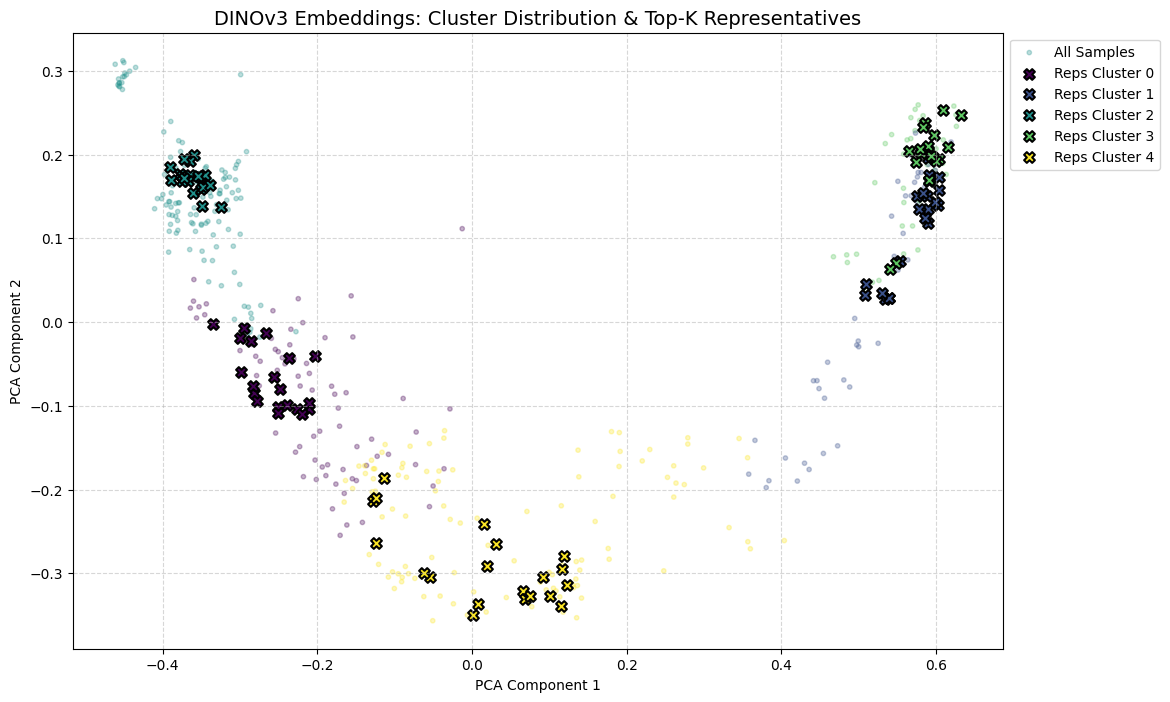

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_clusters_and_representatives(embeddings, representative_dict, n_clusters):
    # 1. Reduce to 2D for plotting
    # We use the raw-ish embeddings here to let the 2D projection find the best visual layout
    pca_2d = PCA(n_components=2)
    coords_2d = pca_2d.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 8))
    
    # 2. Re-calculate labels for coloring background points
    # (Or pass them from your previous function)
    scaler = StandardScaler()
    reduced_50d = PCA(n_components=50).fit_transform(scaler.fit_transform(embeddings))
    kmeans = KMeans(n_clusters=n_clusters,
                     init='k-means++',
                    random_state=24).fit(reduced_50d)
    labels = kmeans.labels_

    # 3. Plot all points (the "background")
    scatter = plt.scatter(coords_2d[:, 0], coords_2d[:, 1], 
                         c=labels, cmap='viridis', s=10, alpha=0.3, label='All Samples')
    
    # 4. Highlight the Top-K representatives for each cluster
    colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))
    
    for i in range(n_clusters):
        rep_indices = representative_dict[f"Cluster_{i}"]
        rep_coords = coords_2d[rep_indices]
        
        plt.scatter(rep_coords[:, 0], rep_coords[:, 1], 
                    edgecolor='black', linewidth=1.5, s=60, 
                    color=colors[i], marker='X', label=f'Reps Cluster {i}')

    plt.title(f"DINOv3 Embeddings: Cluster Distribution & Top-K Representatives", fontsize=14)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    # Clean up legend (too many points make it messy)
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='best', bbox_to_anchor=(1, 1))
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Execution:
reps = get_top_k_representatives(norm_gam_emb, n_clusters=5, top_k=20)
visualize_clusters_and_representatives(norm_gam_emb, reps, n_clusters=5)

### UMAP VIS

In [12]:
import umap
import matplotlib.pyplot as plt

def visualize_with_umap(embeddings, representative_dict, n_clusters):
    # 1. UMAP Projection (from the original high-dim embeddings)
    # n_neighbors: controls local vs global structure (15-50 is usually good)
    # min_dist: controls how tightly points pack (0.1 is standard)
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
    coords_2d = reducer.fit_transform(embeddings)
    
    # 2. Re-labeling based on your K-Means (50D) logic
    scaler = StandardScaler()
    reduced_50d = PCA(n_components=50).fit_transform(scaler.fit_transform(embeddings))
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=24).fit(reduced_50d)
    labels = kmeans.labels_

    plt.figure(figsize=(14, 9))
    
    # 3. Plot background points
    plt.scatter(coords_2d[:, 0], coords_2d[:, 1], c=labels, cmap='Spectral', s=5, alpha=0.2)
    
    # 4. Plot Top-K Representatives
    for i in range(n_clusters):
        rep_idx = representative_dict[f"Cluster_{i}"]
        plt.scatter(coords_2d[rep_idx, 0], coords_2d[rep_idx, 1], 
                    edgecolor='black', s=80, marker='*', label=f'Cluster {i} Reps')

    plt.title("UMAP Projection of DINOv3 Geographical Embeddings", fontsize=15)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

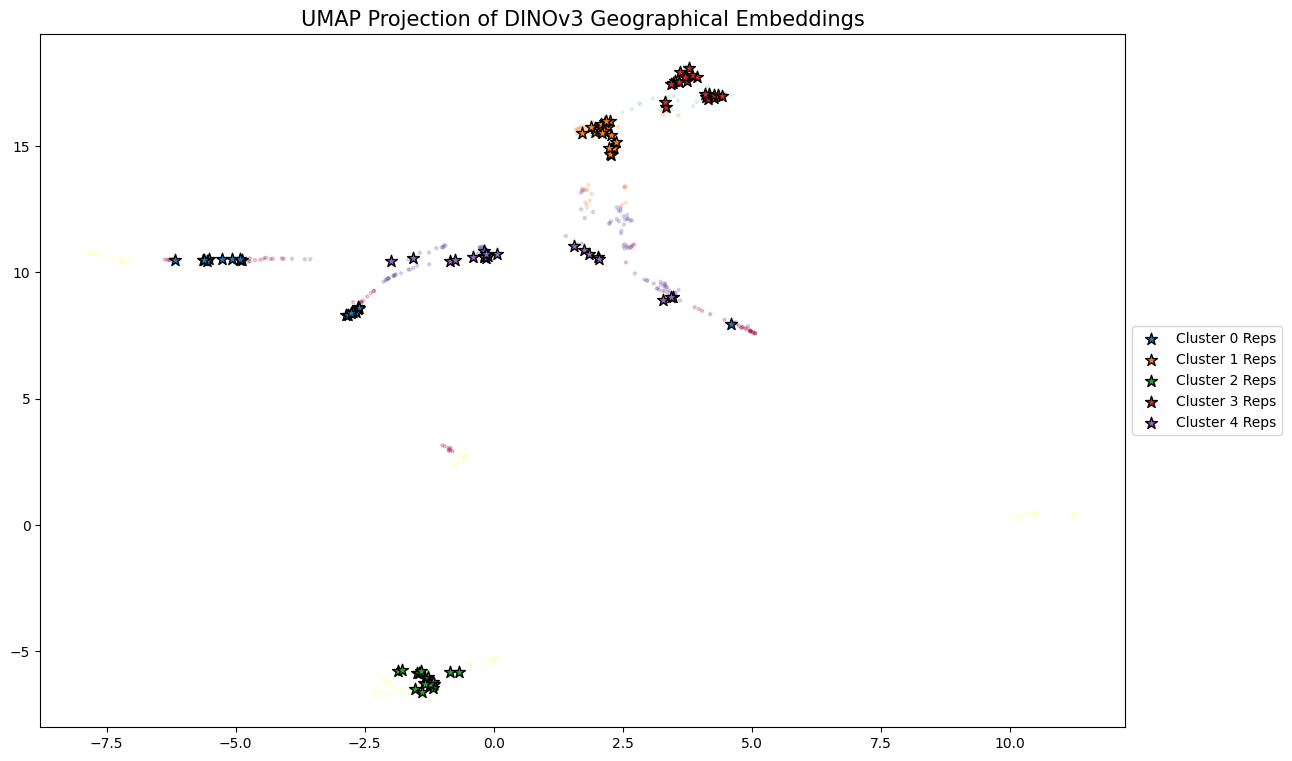

In [ ]:

# Execution:
reps = get_top_k_representatives(norm_gam_emb,
                                n_clusters=5,
                                top_k=20)
visualize_with_umap(norm_gam_emb, reps, n_clusters=5)

## Uniqueness

In [ ]:
from sklearn.neighbors import NearestNeighbors

def compute_manual_uniqueness(embeddings, k=3):
    # Fit KNN
    knn = NearestNeighbors(n_neighbors=k+1, metric='cosine')
    knn.fit(embeddings)
    
    # Find distances to k+1 neighbors (the first one is the point itself, distance=0)
    distances, _ = knn.kneighbors(embeddings)
    
    # Average the distance to the k actual neighbors
    # Higher average distance = more unique
    uniqueness_scores = distances[:, 1:].mean(axis=1)
    
    # Scale 0 to 1
    uniqueness_scores = (uniqueness_scores - uniqueness_scores.min()) / (uniqueness_scores.max() - uniqueness_scores.min())
    return uniqueness_scores

In [16]:
arr_uniq = compute_manual_uniqueness(norm_gam_emb,
                                     k=3)

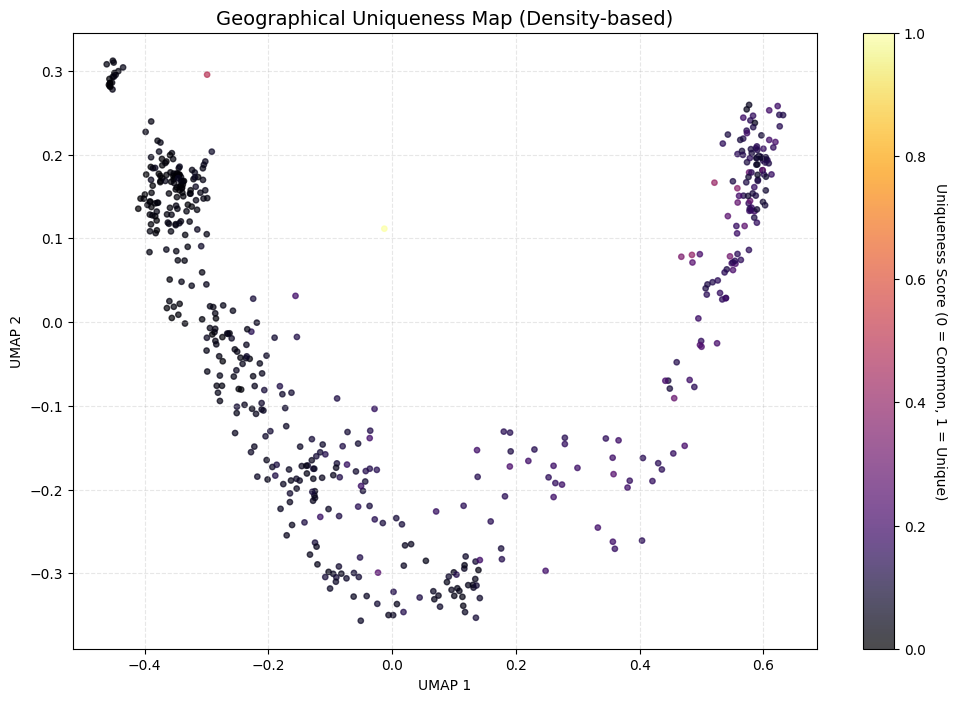

In [24]:
def plot_uniqueness_landscape(coords_2d, uniqueness_scores):
    plt.figure(figsize=(12, 8))
    
    # Create the scatter plot where color (c) is determined by the score
    # 'inferno' or 'magma' are great colormaps for highlighting "hot" outliers
    scatter = plt.scatter(
        coords_2d[:, 0], 
        coords_2d[:, 1], 
        c=uniqueness_scores, 
        cmap='inferno', 
        s=15, 
        alpha=0.7
    )
    
    # Add a colorbar to explain the scale
    cbar = plt.colorbar(scatter)
    cbar.set_label('Uniqueness Score (0 = Common, 1 = Unique)', rotation=270, labelpad=15)
    
    plt.title("Geographical Uniqueness Map (Density-based)", fontsize=14)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

## pca_2d
pca_2d = PCA(n_components=2)
coords_2d = pca_2d.fit_transform(norm_gam_emb)

## using UMAP norm_gam_emb
# reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
# coords_2d = reducer.fit_transform(embeddings)  
#  
plot_uniqueness_landscape(coords_2d,
                          arr_uniq)

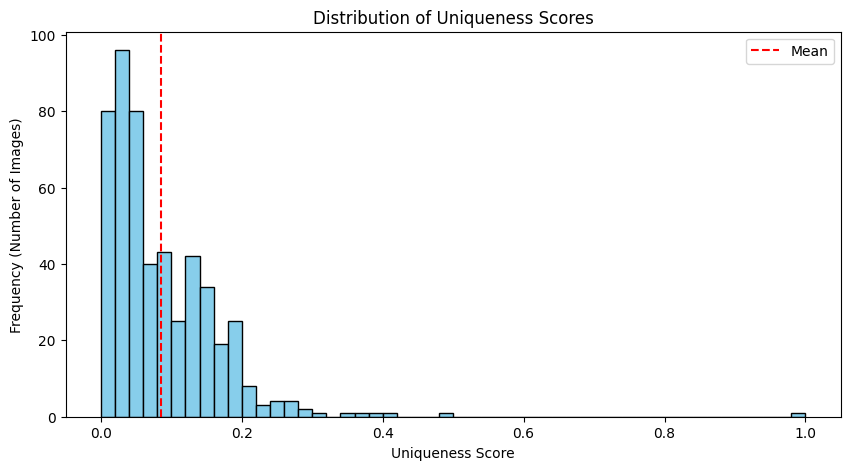

In [20]:
def plot_uniqueness_distribution(uniqueness_scores):
    plt.figure(figsize=(10, 5))
    plt.hist(uniqueness_scores, bins=50, color='skyblue', edgecolor='black')
    plt.axvline(np.mean(uniqueness_scores), color='red', linestyle='dashed', label='Mean')
    
    plt.title("Distribution of Uniqueness Scores")
    plt.xlabel("Uniqueness Score")
    plt.ylabel("Frequency (Number of Images)")
    plt.legend()
    plt.show()

plot_uniqueness_distribution(arr_uniq)

In [21]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def compute_weighted_uniqueness(embeddings, weights=[0.6, 0.3, 0.1]):
    k = len(weights)
    
    # 1. Fit KNN using Cosine Distance (standard for DINOv3)
    # We look for k+1 because the 1st neighbor is always the point itself (dist=0)
    knn = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
    knn.fit(embeddings)
    
    # 2. Extract distances
    # distances shape: (num_samples, k+1)
    distances, _ = knn.kneighbors(embeddings)
    
    # 3. Apply the Weights [0.6, 0.3, 0.1]
    # We slice dists[:, 1:] to ignore the 0-distance to self
    relevant_dists = distances[:, 1:]
    
    # FiftyOne Style: Weighted Mean
    weighted_dists = np.mean(relevant_dists * weights, axis=1)
    
    # 4. Normalize to [0, 1] for common footing
    # This ensures that '1.0' is always the most unique item in THIS dataset
    if weighted_dists.max() > 0:
        weighted_dists /= weighted_dists.max()
        
    return weighted_dists

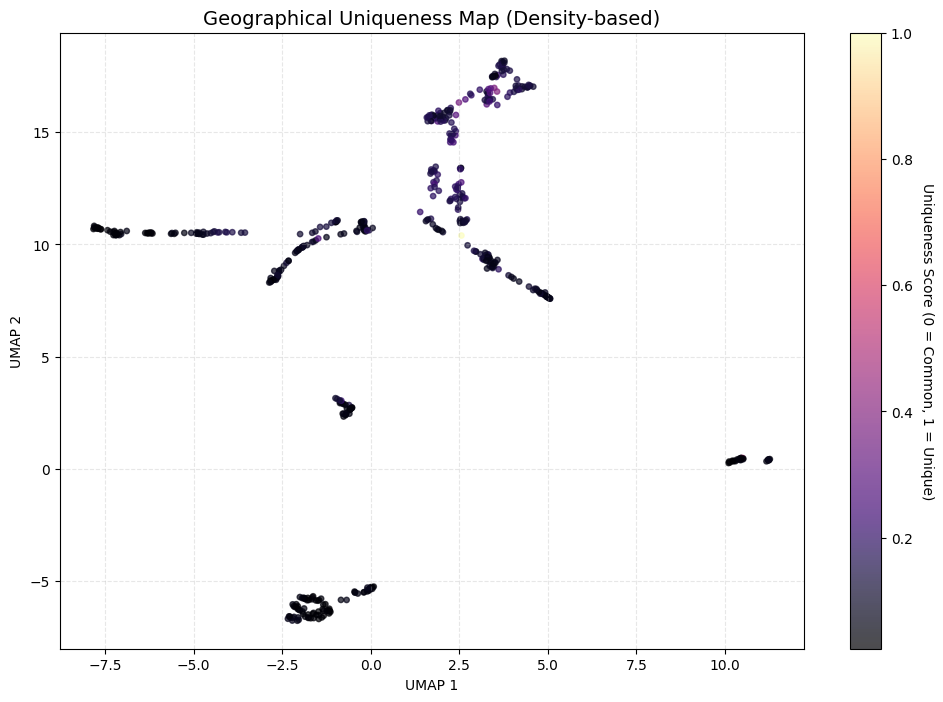

In [22]:
weight_dist = compute_weighted_uniqueness(norm_gam_emb,
                                          weights = [0.6, 0.3,0.1])
plot_uniqueness_landscape(norm_gam_emb,
                        weight_dist)

### Compute Uniqueness in Fiftyone

In [26]:
import fiftyone.brain as fob

In [28]:
uniquess = fob.compute_uniqueness(dataset,
                                  embeddings=dataset.values("full_embeddings"),
                                  uniqueness_field= "uniqueness",
                                  )

Computing uniqueness...
Uniqueness computation complete
